In [1]:
!nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files
from neuron import h
from neuron.units import ms, mV
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', ylabel = 'Frequency/Hz', label='',ynum_decimals =1):
    if color:
        ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
    else:
        ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

h.load_file('nrngui.hoc')
h.load_file("import3d.hoc")
from neuron import h
import numpy as np
import random
import math


#import of the dictionary with the conductance
from PC_param import pc_param 
class Purkinje_py3:
    def __init__(self):

#Soma        
        self.soma = h.Section(name='soma')
        self.soma.nseg = 1
        self.soma.diam = 29.8
        self.soma.cm = 0.77
        self.soma.L =  29.8
        self.soma.Ra = 122

        self.soma.insert('pas')
        self.soma.e_pas = pc_param['eleak']
        self.soma.g_pas = pc_param['LeakSoma']
        
        self.soma.insert('Cav3_1') 
        self.soma.pcabar_Cav3_1 = pc_param['Cav3.1Soma']
        
        self.soma.insert('Cav2_1') 
        self.soma.pcabar_Cav2_1 = pc_param['Cav2.1Soma']
            
        self.soma.insert('HCN1')
        self.soma.gbar_HCN1 = pc_param['HCNSoma']
        self.soma.eh = -34.4

        self.soma.insert('Nav1_6')
        self.soma.gbar_Nav1_6 = pc_param['Nav1.6Soma']
        self.soma.ena = 60
        
        self.soma.insert('Kv3_4')
        self.soma.gkbar_Kv3_4 = pc_param['Kv3.4Soma']
        self.soma.ek = -88
        
        self.soma.insert('Kv1_1')
        self.soma.gbar_Kv1_1 = pc_param['Kv1.1Soma']
        
        self.soma.insert('Cav3_2')
        self.soma.gcabar_Cav3_2 = pc_param['Cav3.2Soma']
        
        self.soma.insert('Kca3_1')
        self.soma.gkbar_Kca3_1 = pc_param['Kca3.1Soma']
        
        self.soma.insert('Cav3_3')
        self.soma.pcabar_Cav3_3 = pc_param['Cav3.3Soma']

        self.soma.insert('Kir2_3')
        self.soma.gkbar_Kir2_3 = pc_param['PC_KirSoma']
        
        self.soma.insert('Kca1_1')
        self.soma.gbar_Kca1_1 = pc_param['Kca1.1Soma']
        
        self.soma.insert('Kca2_2') 
        self.soma.gkbar_Kca2_2 = pc_param['Kca2.2Soma']
        
        self.soma.insert('cdp5')
        self.soma.Nannuli_cdp5 = 0.326 + (1.94 * (self.soma.diam)) + (0.289*(self.soma.diam)*(self.soma.diam)) - ((3.33e-2)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)) + ((1.55e-3)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)) - (2.55e-5*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam)*(self.soma.diam))
        self.soma.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.soma.diam)/1.4)
        self.soma.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.soma.diam)/2.29)
        self.soma.rf4_cdp5 = 0.000267 + 0.0167* math.exp(-(self.soma.diam)/0.722) + 0.0028* math.exp(-(self.soma.diam)/4)
        
        self.soma.TotalPump_cdp5 = 5e-8
        
        self.soma.push()
        h.pt3dclear()
        h.pt3dadd(0.0, 0, 0.0, 29.8)
        h.pt3dadd(0.0, 29.8, 0.0, 29.8)
        h.pop_section()
        
        self.soma.push()
        h.ion_style("ca_ion", 1, 1, 0, 1, 0) 
        self.soma.eca = 137.52625 
        self.soma.cai = h.cai0_ca_ion
        self.soma.cao = h.cao0_ca_ion
        h.pop_section()

#Dend coordinate
        self.sectioncoordinate = np.genfromtxt("coordinate.csv")

        fh = open("PC_dendnames.dlist")
        self.dendnames = [line[:-1] for line in fh.readlines()]
        
        self.dend = []
        for i_idx,i in enumerate(self.sectioncoordinate):
            self.dend.append(h.Section(name=self.dendnames[i_idx]))
            self.dend[-1].push()
            h.pt3dclear()
            h.pt3dadd(i.item(1), i.item(2), i.item(3), i.item(4))
            h.pt3dadd(i.item(5), i.item(6), i.item(7), i.item(8))
            self.dend[-1].diam = i.item(4)

            self.dend[-1].insert('cdp5')
            self.dend[-1].Nannuli_cdp5 = 0.326 + (1.94 * (i.item(8))) + (0.289*(i.item(8))*(i.item(8))) - ((3.33e-2)*(i.item(8))*(i.item(8))*(i.item(8))) + ((1.55e-3)*(i.item(8))*(i.item(8))*(i.item(8))*(i.item(8))) - (2.55e-5*(i.item(8))*(i.item(8))*(i.item(8))*(i.item(8))*(i.item(8)))
            self.dend[-1].Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(i.item(8))/1.4)
            self.dend[-1].rf3_cdp5 = 0.162 - 0.106* math.exp(-(i.item(8))/2.29)
            if ((i.item(8))>=2):
                self.dend[-1].rf4_cdp5 = 0.000267 + 0.0167* math.exp(-(i.item(8))/0.722) + 0.0028* math.exp(-(i.item(8))/4)
            else:
                self.dend[-1].rf4_cdp5 = 0.003
            
            h.pop_section()

#Connection between dend and soma  
        self.dend[0].connect(self.soma,1,0)

#Connection between each dend	
        for c in np.genfromtxt("connections.csv"):
            self.dend[int(c[0])].connect(self.dend[int(c[2])],int(c[3]),int(c[1]))
	   

        self.subsets = np.genfromtxt("ModelViewParmSubset.txt", dtype = int)
        self.ModelViewParmSubset = [[self.dend[int(i)] for i in self.subsets[np.where(self.subsets[...,1]==M),0][0]] for M in range(88) ]
        for d in self.dend:
            
            d.Ra = 122
            
            d.insert('pas')
            d.e_pas = pc_param['eleak']
    
            d.insert('Cav2_1') 
            d.pcabar_Cav2_1 = pc_param['Cav2.1Dend']
        
            d.insert('Kca1_1')
            d.gbar_Kca1_1 = pc_param['Kca1.1Dend']
            
            d.insert('Kv4_3')
            d.gkbar_Kv4_3 = pc_param['Kv4.3Dend']

            d.insert('Kv1_1')
            d.gbar_Kv1_1 = pc_param['Kv1.1Dend']
            
            d.insert('Kv1_5')
            d.gKur_Kv1_5 = pc_param['Kv1.5Dend']
            
            d.insert('Kv3_3')
            d.gbar_Kv3_3 = pc_param['Kv3.3Dend']
            
            d.insert('Cav3_3')
            d.pcabar_Cav3_3 = pc_param['Cav3.3Dend']
            
            d.insert('HCN1')
            d.gbar_HCN1 = pc_param['HCNDend']
            d.eh = -34.4
                
            if d.diam >= 3.5 and d.diam <= 12: 
                d.insert('Cav3_2')
                d.gcabar_Cav3_2 = pc_param['Cav3.2Dend']
                
                d.insert('Kca3_1') 
                d.gkbar_Kca3_1 = pc_param['Kca3.1Dend']
                
                d.insert('Cav3_1') 
                d.pcabar_Cav3_1 = pc_param['Cav3.1Dend']
                
                d.insert('Kca2_2') 
                d.gkbar_Kca2_2 = pc_param['Kca2.2Dend']
                
                d.insert('Kir2_3')
                d.gkbar_Kir2_3 = pc_param['PC_KirDend']
                
                if d.diam >=8 and d.diam <=12:
                    d.insert('Nav1_6')
                    d.gbar_Nav1_6 = pc_param['Nav1.6Dend']
                    d.ena = 60
                
            d.TotalPump_cdp5 = 2e-8
            
            d.ek = -88
            
            d.push()
            d.eca = 137.52625
            d.cai = h.cai0_ca_ion
            d.cao = h.cao0_ca_ion
            h.ion_style("ca_ion", 1, 1, 0, 1, 0)
            h.pop_section()
            
            
            
	      
        self.subsets_cm = np.genfromtxt("ModelViewParmSubset_cm.txt")
        for cm in self.subsets_cm:
            for d in self.ModelViewParmSubset[int(cm[0])]:
                d.cm = cm[1] * 0.77/1.64

        self.dend[138].cm = 8.58298 * 0.77/1.64

        self.subsets_paraextra = np.genfromtxt("modelsubsetextra.txt", dtype=[('modelviewsubset','f8'),('channel','U4'),('channel2','U4'),('value','f8')], delimiter=" ")
        for para in self.subsets_paraextra:
            for d in self.ModelViewParmSubset[int(para[0])]:
                d.insert(para[1])
                exec('d.gmax_'+para[2]+' = '+str(para[3]))
	
        listgmax = []
        for d in self.ModelViewParmSubset[2]:
            d.g_pas = d.g_pas/2
            
        self.dend[138].insert('pas')
        self.dend[138].g_pas = 1.74451E-4 / 2
 	
#Axon AIS. First section after the soma
        self.axonAIS = h.Section(name='axonAIS')
        self.axonAIS.nseg = 1
        self.axonAIS.diam = 0.97 
        self.axonAIS.cm = 0.77
        self.axonAIS.L = 17
        self.axonAIS.Ra = 122
        
        self.axonAIS.insert('pas')
        self.axonAIS.e_pas = pc_param['eleak']
        self.axonAIS.g_pas = 0.0003
        
        self.axonAIS.insert('Nav1_6')
        self.axonAIS.gbar_Nav1_6 = pc_param['Nav1.6AIS']
        self.axonAIS.ena = 75	
        
        self.axonAIS.insert('Cav3_1') 
        self.axonAIS.pcabar_Cav3_1 = pc_param['Cav3.1Ais']
        
        self.axonAIS.insert('Cav2_1') 
        self.axonAIS.pcabar_Cav2_1 = pc_param['Cav2.1AIS']
        
        self.axonAIS.insert('Kv3_4')
        self.axonAIS.gkbar_Kv3_4 = pc_param['Kv3.4AIS']
        self.axonAIS.ek = -88
        
        self.axonAIS.insert('cdp5')
        self.axonAIS.Nannuli_cdp5 = 0.326 + (1.94 * (self.axonAIS.diam)) + (0.289*(self.axonAIS.diam)*(self.axonAIS.diam)) - ((3.33e-2)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)) + ((1.55e-3)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)) - (2.55e-5*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam)*(self.axonAIS.diam))
        self.axonAIS.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axonAIS.diam)/1.4)
        self.axonAIS.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axonAIS.diam)/2.29)
        self.axonAIS.rf4_cdp5 = 0.003

        self.axonAIS.TotalPump_cdp5 = 5e-8
        
        self.axonAIS.push()
        h.ion_style("ca_ion", 1, 1, 0, 1, 0) 
        self.axonAIS.eca = 137.52625
        self.axonAIS.cai = h.cai0_ca_ion
        self.axonAIS.cao = h.cao0_ca_ion
        h.pop_section()
	
#AISK	
        self.axonAISK = h.Section(name='axonAISK')
        self.axonAISK.nseg = 1
        self.axonAISK.diam = 0.97 
        self.axonAISK.cm = 0.77
        self.axonAISK.L = 4 
        self.axonAISK.Ra = 122
        
        self.axonAISK.insert('pas')
        self.axonAISK.e_pas = pc_param['eleak']
        self.axonAISK.g_pas = 0.0003
        
        self.axonAISK.insert('Kv1_1')
        self.axonAISK.gbar_Kv1_1 = pc_param['Kv1.1AisK']
        self.axonAISK.ek = -88
	
#First Myelination
        self.axonmyelin = h.Section(name='axonmyelin')
        self.axonmyelin.nseg = 1
        self.axonmyelin.diam = 0.73
        self.axonmyelin.L = 100

        self.axonmyelin.insert('pas') 
        self.axonmyelin.e_pas = -63 
        self.axonmyelin.g_pas = 5.60e-9 
        self.axonmyelin.cm = 1.87e-11
        self.axonmyelin.Ra = 122	
	
#First Node of Ranvier
        self.axonNOR = h.Section(name='axonNOR')
        self.axonNOR.nseg = 1
        self.axonNOR.diam = 0.73 
        self.axonNOR.cm = 0.77
        self.axonNOR.L = 4 
        self.axonNOR.Ra = 122
        
        self.axonNOR.insert('pas')
        self.axonNOR.e_pas = pc_param['eleak']
        self.axonNOR.g_pas = 0.0003
        
        self.axonNOR.insert('Nav1_6')
        self.axonNOR.gbar_Nav1_6 = pc_param['Nav1.6Nor']
        self.axonNOR.ena = 60

        self.axonNOR.insert('Kv3_4')
        self.axonNOR.gkbar_Kv3_4 = pc_param['Kv3.4Nor']
        self.axonNOR.ek = -88
            
        self.axonNOR.insert('cdp5')
        self.axonNOR.Nannuli_cdp5 = 0.326 + (1.94 * (self.axonNOR.diam)) + (0.289*(self.axonNOR.diam)*(self.axonNOR.diam)) - ((3.33e-2)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)) + ((1.55e-3)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)) - (2.55e-5*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam)*(self.axonNOR.diam))
        self.axonNOR.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axonNOR.diam)/1.4)
        self.axonNOR.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axonNOR.diam)/2.29)
        self.axonNOR.rf4_cdp5 = 0.003
            
        self.axonNOR.insert('Cav3_1') 
        self.axonNOR.pcabar_Cav3_1 = pc_param['Cav3.1Nor']
        
        self.axonNOR.insert('Cav2_1') 
        self.axonNOR.pcabar_Cav2_1 = pc_param['Cav2.1Nor']
        
        self.axonNOR.TotalPump_cdp5 = 5e-7
	
#second part of the axon
        self.axonmyelin2 = h.Section(name='axonmyelin2')
        self.axonmyelin2.nseg = 1
        self.axonmyelin2.diam = 0.73
        self.axonmyelin2.L = 100 
        
        self.axonmyelin2.insert('pas') 
        self.axonmyelin2.e_pas = -63 
        self.axonmyelin2.g_pas = 5.60e-9 
        self.axonmyelin2.cm = 1.87e-11 
        self.axonmyelin2.Ra = 122
	
#Second Node of Ranvier	
        self.axonNOR2 = h.Section(name='axonNOR2')
        self.axonNOR2.nseg = 1
        self.axonNOR2.diam = 0.73 
        self.axonNOR2.cm = 0.77
        self.axonNOR2.L = 4 
        self.axonNOR2.Ra = 122
        
        self.axonNOR2.insert('pas')
        self.axonNOR2.e_pas = pc_param['eleak']
        self.axonNOR2.g_pas = 0.0003
        
        self.axonNOR2.insert('Nav1_6')
        self.axonNOR2.gbar_Nav1_6 = pc_param['Nav1.6Nor2']
        self.axonNOR2.ena = 60

        self.axonNOR2.insert('Kv3_4')
        self.axonNOR2.gkbar_Kv3_4 = pc_param['Kv3.4Nor2']
        self.axonNOR2.ek = -88

        self.axonNOR2.insert('cdp5')
        self.axonNOR2.Nannuli_cdp5 = 0.326 + (1.94 * (self.axonNOR2.diam)) + (0.289*(self.axonNOR2.diam)*(self.axonNOR2.diam)) - ((3.33e-2)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)) + ((1.55e-3)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)) - (2.55e-5*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam)*(self.axonNOR2.diam))
        self.axonNOR2.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axonNOR2.diam)/1.4)
        self.axonNOR2.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axonNOR2.diam)/2.29)
        self.axonNOR2.rf4_cdp5 = 0.003
        
        self.axonNOR2.insert('Cav3_1') 
        self.axonNOR2.pcabar_Cav3_1 = pc_param['Cav3.1Nor2']
        
        self.axonNOR2.insert('Cav2_1') 
        self.axonNOR2.pcabar_Cav2_1 = pc_param['Cav2.1Nor2']
        
        self.axonNOR2.TotalPump_cdp5 = 5e-7
	
#Third part of the axon
        self.axonmyelin3 = h.Section(name='axonmyelin3')
        self.axonmyelin3.nseg = 1
        self.axonmyelin3.diam = 0.73
        self.axonmyelin3.L = 100 
        
        self.axonmyelin3.insert('pas') 
        self.axonmyelin3.e_pas = -63 
        self.axonmyelin3.g_pas = 5.60e-9 
        self.axonmyelin3.cm = 1.87e-11 
        self.axonmyelin3.Ra = 122
	
#Third Node of Ranvier
        self.axonNOR3 = h.Section(name='axonNOR3')
        self.axonNOR3.nseg = 1
        self.axonNOR3.diam = 0.73 
        self.axonNOR3.cm = 0.77
        self.axonNOR3.L = 4 
        self.axonNOR3.Ra = 122
        
        self.axonNOR3.insert('pas')
        self.axonNOR3.e_pas = pc_param['eleak']
        self.axonNOR3.g_pas = 0.0003
        
        self.axonNOR3.insert('Nav1_6')
        self.axonNOR3.gbar_Nav1_6 = pc_param['Nav1.6Nor3']
        self.axonNOR3.ena = 60

        self.axonNOR3.insert('Kv3_4')
        self.axonNOR3.gkbar_Kv3_4 = pc_param['Kv3.4Nor3']
        self.axonNOR3.ek = -88
        
        self.axonNOR3.insert('cdp5')
        self.axonNOR3.Nannuli_cdp5 = 0.326 + (1.94 * (self.axonNOR3.diam)) + (0.289*(self.axonNOR3.diam)*(self.axonNOR3.diam)) - ((3.33e-2)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)) + ((1.55e-3)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)) - (2.55e-5*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam)*(self.axonNOR3.diam))
        self.axonNOR3.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axonNOR3.diam)/1.4)
        self.axonNOR3.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axonNOR3.diam)/2.29)
        self.axonNOR3.rf4_cdp5 = 0.003
        
        self.axonNOR3.insert('Cav3_1') 
        self.axonNOR3.pcabar_Cav3_1 = pc_param['Cav3.1Nor3']
        
        self.axonNOR3.insert('Cav2_1') 
        self.axonNOR3.pcabar_Cav2_1 = pc_param['Cav2.1Nor3']
        
        self.axonNOR3.TotalPump_cdp5 = 5e-7
	
#Third part of the axon
        self.axonmyelin4 = h.Section(name='axonmyelin4')
        self.axonmyelin4.nseg = 1
        self.axonmyelin4.diam = 0.73
        self.axonmyelin4.L = 100 
        
        self.axonmyelin4.insert('pas') 
        self.axonmyelin4.e_pas = -63 
        self.axonmyelin4.g_pas = 5.60e-9 
        self.axonmyelin4.cm = 1.87e-11 
        self.axonmyelin4.Ra = 122
	  
#Collateral.
        self.axoncoll = h.Section(name='axoncoll')
        self.axoncoll.nseg = 1
        self.axoncoll.diam = 0.6
        self.axoncoll.L = 100
        self.axoncoll.Ra = 122

        self.axoncoll.insert('pas')
        self.axoncoll.e_pas = pc_param['eleak']
        self.axoncoll.g_pas = 0.0003
        
        self.axoncoll.insert('Nav1_6')
        self.axoncoll.gbar_Nav1_6 = pc_param['Nav1.6Axoncoll']
        self.axoncoll.ena = 60

        self.axoncoll.insert('Kv3_4')
        self.axoncoll.gkbar_Kv3_4 = pc_param['Kv3.4Axoncoll']
        self.axoncoll.ek = -88
        
        self.axoncoll.insert('Cav3_1') 
        self.axoncoll.pcabar_Cav3_1 = pc_param['Cav3.1Axoncoll']
        
        self.axoncoll.insert('Cav2_1') 
        self.axoncoll.pcabar_Cav2_1 = pc_param['Cav2.1Axoncoll']
        
        self.axoncoll.insert('cdp5')
        self.axoncoll.Nannuli_cdp5 = 0.326 + (1.94 * (self.axoncoll.diam)) + (0.289*(self.axoncoll.diam)*(self.axoncoll.diam)) - ((3.33e-2)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)) + ((1.55e-3)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)) - (2.55e-5*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam)*(self.axoncoll.diam))
        self.axoncoll.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axoncoll.diam)/1.4)
        self.axoncoll.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axoncoll.diam)/2.29)
        self.axoncoll.rf4_cdp5 = 0.003
            
        self.axoncoll.TotalPump_cdp5 = 5e-7
        
        self.axoncoll.push()
        h.ion_style("ca_ion", 1, 1, 0, 1, 0) 
        self.axoncoll.eca = 137.52625
        self.axoncoll.cai = h.cai0_ca_ion
        self.axoncoll.cao = h.cao0_ca_ion
        h.pop_section()
        
#Collateral second part
        self.axoncoll2 = h.Section(name='axoncoll2')
        self.axoncoll2.nseg = 1
        self.axoncoll2.diam = 0.6
        self.axoncoll2.L = 100
        self.axoncoll2.Ra = 122

        self.axoncoll2.insert('pas')
        self.axoncoll2.e_pas = pc_param['eleak']
        self.axoncoll2.g_pas = 0.0003
        
        self.axoncoll2.insert('Nav1_6')
        self.axoncoll2.gbar_Nav1_6 = pc_param['Nav1.6Axoncoll']
        self.axoncoll2.ena = 60


        self.axoncoll2.insert('Kv3_4')
        self.axoncoll2.gkbar_Kv3_4 = pc_param['Kv3.4Axoncoll']
        self.axoncoll2.ek = -88
        
        self.axoncoll2.insert('cdp5')
        self.axoncoll2.Nannuli_cdp5 = 0.326 + (1.94 * (self.axoncoll2.diam)) + (0.289*(self.axoncoll2.diam)*(self.axoncoll2.diam)) - ((3.33e-2)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)) + ((1.55e-3)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)) - (2.55e-5*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam)*(self.axoncoll2.diam))
        self.axoncoll2.Buffnull2_cdp5 = 64.2 - 57.3* math.exp(-(self.axoncoll2.diam)/1.4)
        self.axoncoll2.rf3_cdp5 = 0.162 - 0.106* math.exp(-(self.axoncoll2.diam)/2.29)
        self.axoncoll2.rf4_cdp5 = 0.003
        
        self.axoncoll2.insert('Cav3_1') 
        self.axoncoll2.pcabar_Cav3_1 = pc_param['Cav3.1Axoncoll']
        
        self.axoncoll2.insert('Cav2_1') 
        self.axoncoll2.pcabar_Cav2_1 = pc_param['Cav2.1Axoncoll']
        
        self.axoncoll2.TotalPump_cdp5 = 5e-7
        
        self.axoncoll2.push()
        h.ion_style("ca_ion", 1, 1, 0, 1, 0) 
        self.axoncoll2.eca = 137.52625
        self.axoncoll2.cai = h.cai0_ca_ion
        self.axoncoll2.cao = h.cao0_ca_ion
        h.pop_section()
	  
#Connections of the axon	  
        self.axonAIS.connect(self.soma,1,0)
        self.axonAISK.connect(self.axonAIS,1,0)
        self.axonmyelin.connect(self.axonAISK,1,0)		
        self.axonNOR.connect(self.axonmyelin,1,0)
        self.axonmyelin2.connect(self.axonNOR,1,0)
        self.axonNOR2.connect(self.axonmyelin2,1,0)
        self.axonmyelin3.connect(self.axonNOR2,1,0)
        self.axonNOR3.connect(self.axonmyelin3,1,0)
        self.axonmyelin4.connect(self.axonNOR3,1,0)
        
        
        self.axoncoll.connect(self.axonNOR2,1,0)
        self.axoncoll2.connect(self.axoncoll,1,0)

#vectors for the time and voltage in the soma and axon.
	  	       		    
        self.rec_t = h.Vector()
        self.rec_t.record(h._ref_t)

        self.vm_soma = h.Vector()
        self.vm_soma.record(self.soma(0.5)._ref_v)
        
        self.vm_NOR3 = h.Vector()
        self.vm_NOR3.record(self.axonNOR3(0.5)._ref_v)


/home/wzl/anaconda/envs/cerebellum/bin/nrnivmodl:10: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import working_set
/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015
Mod files: "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files/Cav2_1.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files/Cav3_1.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files//home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files/Cav3_2.mod" "/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/purkinjecell_2015/mod_files//home/wzl/L

--No graphics will be displayed.


In [3]:
from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位
def plot_curve(ax2,x,y,color='black',title='', linestyle='-',linewidth=2, xlim=[0,100],dx=20,
               ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', 
               ylabel = 'Frequency/Hz', label='',ynum_decimals =1, facecolors='none',
               nonscatter=True, s0=10, facecolor='none'):
    if nonscatter:
        if color:
            ax2.plot(x,y,color=color,linewidth=linewidth,linestyle=linestyle,alpha=alpha, label=label)
        else:
            ax2.plot(x,y,linewidth=linewidth,alpha=alpha, linestyle=linestyle,label=label)
    else:
        if color:
            ax2.scatter(x,y,edgecolors=color,facecolors = facecolor, alpha=alpha, 
                        label=label, s=s0)
        else:
            ax2.scatter(x,y, alpha=alpha, label=label,
                        s=s0)
        
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
        # ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if xlim:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

In [2]:
neuron = Purkinje_py3()
len(neuron.dend)

1599

In [13]:
def est_GL_C(run_dt):
  
    neuron = Purkinje_py3()
    h.dt = run_dt
    h.tstop = 1000.
    h.v_init = 65.
        
    time = h.Vector().record(h._ref_t)
    recv = h.Vector().record(neuron.soma(0.5)._ref_v)
    

    # Initialize voltage clamp
    iclamp = h.IClamp(neuron.soma(0.5))
    iclamp.delay = 200.
    iclamp.dur = h.tstop - 500.
    iclamp.amp = 0.
    
    i_clamp = h.Vector().record(iclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()
        
    def verfication(GL, C, t, I):
        
        v = np.zeros(len(t))
        for i in range(len(t)-1):
            v[i+1] = v[i] + run_dt/C*(-GL*v[i]+I[i])
            
        return v
        
        
    # Main simulation loop
    def main():
    
        i_amp = np.arange(1,10)*0.004
        C = np.zeros(len(i_amp))
        GL = np.zeros(len(i_amp))
        iclamp.amp = 0.
        go()
        recv0 = np.array(recv.to_python())
        V_rest = recv0[-1]
        print(V_rest)
        
        for i in range(len(i_amp)):      
            
            iclamp.amp = i_amp[i]
            go()
            recv0 = np.array(recv.to_python())
            i0 = np.array(i_clamp.to_python())
            time0 = np.array(time.to_python())
            plt.plot(time0, recv0-V_rest, color='r')
            recv_norm = recv0 - V_rest
            GL[i] = i_amp[i]*1e-3/recv_norm[7000]
            
            y = np.log(recv_norm[7000:7300])
            A = np.ones((len(time0[7000:7300]),2))
            A[:,0] = time0[7000:7300]
            x, residuals, rank, singular_values = np.linalg.lstsq(A, y, rcond=None)
            tau_decay = -1./x[0] 
            C[i] = tau_decay*GL[i]
            v = verfication(GL[i], C[i], time0, i0*1e-3)
            # v_tune = verfication(0.011, 0.31, time0, i0)
            plt.plot(time0, v, 'b')
            plt.xlim([650,750])
            # plt.plot(time0, v_tune, 'k')
            # plt.legend()
        return  GL,C
    
    GL,C = main()
    return  GL,C

In [ ]:
run_dt = 0.1
neuron = Purkinje_py3()
h.dt = run_dt
h.tstop = 500.
h.v_init = -65.84
    
time = h.Vector().record(h._ref_t)
recv = h.Vector().record(neuron.soma(0.5)._ref_v)


# Initialize voltage clamp
iclamp = h.IClamp(neuron.soma(0.5))
iclamp.delay = 200.
iclamp.dur = 200.
iclamp.amp = 0.

i_clamp = h.Vector().record(iclamp._ref_i)

# Function to initialize the simulation
def initialize():
    h.t = 0
    h.finitialize(h.v_init)
    h.fcurrent()

# Function to integrate the simulation
def integrate():
    while h.t < h.tstop:
        h.fadvance()

# Function to run the simulation
def go():
    initialize()
    integrate()
    
def verfication(GL, C, t, I):
    
    v = np.zeros(len(t))
    for i in range(len(t)-1):
        v[i+1] = v[i] + run_dt/C*(-GL*v[i]+I[i])
        
    return v
        
        

i_amp = np.arange(1,2)*0.0
C = np.zeros(len(i_amp))
GL = np.zeros(len(i_amp))
iclamp.amp = 0.
go()
recv0 = np.array(recv.to_python())
V_rest = recv0[-1]
print(V_rest)

for i in range(len(i_amp)):      
    
    iclamp.amp = i_amp[i]
    go()
    recv0 = np.array(recv.to_python())
    i0 = np.array(i_clamp.to_python())
    time0 = np.array(time.to_python())
    plt.plot(time0, recv0-V_rest, color='r')
    recv_norm = recv0 - V_rest
    GL[i] = i_amp[i]*1e-3/recv_norm[4000]
    
    y = np.log(recv_norm[4000:4100])
    A = np.ones((len(time0[4000:4100]),2))
    A[:,0] = time0[4000:4100]
    x, residuals, rank, singular_values = np.linalg.lstsq(A, y, rcond=None)
    tau_decay = -1./x[0] 
    C[i] = tau_decay*GL[i]
    v = verfication(GL[i], C[i], time0, i0*1e-3)
    # v_tune = verfication(0.011, 0.31, time0, i0)
    plt.plot(time0, v, 'b')
    # plt.xlim([650,750])


In [48]:
recv0[4000]

-65.84832151253157

In [46]:
print(np.mean(C))
print(np.mean(GL))

0.0006275253259611378
0.0002173680668463284


In [4]:
def eff_cond_est_two(run_dt, fE, fI, C=0.0006275253259611378, GL = 0.0002173680668463284, locE=58, locI=37,
                         plot =False):
    
    neuron = Purkinje_py3()
        
    h.dt = run_dt
    h.tstop = 500.
    h.v_init =  -65.84
    Vclamp_init =  -65.84

    recv = h.Vector().record(neuron.soma(0.5)._ref_v)
    
    # Initialize an excitatory and inhibitory synaptic input
    # make a new stimulator
    stimE = h.NetStim()
    stimI = h.NetStim()

    synE = h.Exp2Syn(neuron.dend[int(locE)](0.5))
    synI = h.Exp2Syn(neuron.dend[int(locI)](0.5))
    synE.tau1 = 1.  # ms
    synE.tau2 = 5.  # ms
    synI.tau1 = 1.  # ms
    synI.tau2 = 5.  # ms

    synE.e = 0.  # mV for E input and -80 for I input 
    synI.e = -100.
        
    stimE.number = 1
    stimE.start = h.tstop - 100.  # ms
    stimI.number = 1
    stimI.start = h.tstop - 100.  # ms
    ncstimE = h.NetCon(stimE, synE)
    ncstimE.delay = 0.
    ncstimE.weight[0] = 0e-2  # uS
    ncstimI = h.NetCon(stimI, synI)
    ncstimI.delay = 0.
    ncstimI.weight[0] = 0e-2  # uS


    # Initialize voltage clamp
    vclamp = h.SEClamp(neuron.soma(0.5))
    vclamp.amp1 = Vclamp_init
    vclamp.dur1 = h.tstop
    vclamp.dur2 = h.tstop
    vclamp.amp2 = Vclamp_init - 20.

    irec = h.Vector()
    irec.record(vclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():

        Vclamp = np.arange(-110.,-60.,10)
        tstart = int(stimI.start/run_dt+1)
        V_rest = -65.84832151253157
        epsilonE = 0. - V_rest
        epsilonI = -100. - V_rest
        epsilonI1 = -120. - V_rest
        
        #  pure E for the estimation of true GE_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = fE
        ncstimI.weight[0] = 0.
        go()
        recvE0 = np.array(recv.to_python())
        recvE0_norm = recvE0[tstart:tstart+1000] - V_rest
        dVdtE = np.diff(recvE0_norm)/run_dt
        dVdtE = np.append(dVdtE, 0)
        GE_est = (C*dVdtE + GL*recvE0_norm)/(epsilonE - recvE0_norm)
        
        #  pure I input for the estimation of GI_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = 0.
        ncstimI.weight[0] = fI
        go()
        recvI0 = np.array(recv.to_python())
        recvI0_norm = recvI0[tstart:tstart+1000] - V_rest
        dVdtI = np.diff(recvI0_norm)/run_dt
        dVdtI = np.append(dVdtI, 0)
        GI_est = (C*dVdtI + GL*recvI0_norm)/(epsilonI - recvI0_norm)
        if plot:
            plt.plot(recvE0_norm, 'r')
            plt.plot(recvI0_norm, 'b')
        
        
    
        Isyn_inj_t = np.zeros((len(Vclamp),1000))
        Isyn_epsilonI1_inj_t = np.zeros((len(Vclamp),1000))

        

        for i in range(len(Vclamp)):
            ncstimE.weight[0] = 0.
            ncstimI.weight[0] = 0.
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj0 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            
            synE.e = 0.
            synI.e = -100.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn = (Iinj1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_inj_t[i,:] = Isyn
            
            synE.e = 0.
            synI.e = -120.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1_epsilonI1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn_epsilonI1 =  (Iinj1_epsilonI1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_epsilonI1_inj_t[i,:] = Isyn_epsilonI1
            
                                                         
        traditional_effective_conductance = np.zeros((2,1000))
        intercept_effective_conductance = np.zeros((2,1000))
        A = np.ones((len(Vclamp),2))
        A[:,0] = Vclamp - V_rest
        epsilonE = 0. - V_rest
        epsilonI = -100. - V_rest
        epsilonI1 = -120. - V_rest
        for i in range(1000):
            x, residuals, rank, singular_values = np.linalg.lstsq(A, Isyn_inj_t[:,i], 
                                                                  rcond=None)
            x_epsilonI1, residuals, rank, singular_values = np.linalg.lstsq(A, 
                                Isyn_epsilonI1_inj_t[:,i], rcond=None)
            
            traditional_effective_conductance[1, i] = (x[0]*epsilonE + x[1])/(epsilonE - epsilonI)
            traditional_effective_conductance[0, i] = (x[0]*epsilonI + x[1])/(epsilonI - epsilonE)
           
            intercept_effective_conductance[1,i] = (x[1] - x_epsilonI1[1])/(epsilonI1 - epsilonI)
            intercept_effective_conductance[0,i] = (-intercept_effective_conductance[1,i]*epsilonI - x[1])/epsilonE
            
        
        return intercept_effective_conductance, traditional_effective_conductance, GE_est, GI_est
    
    
    intercept_effective_conductance, traditional_effective_conductance,GE_est, GI_est = main()
    return intercept_effective_conductance, traditional_effective_conductance,GE_est, GI_est

In [5]:
intercept_effective_conductance, traditional_effective_conductance,GE_est, GI_est = eff_cond_est_two(0.1, 1e-3, 1e-3, C=0.0006275253259611378, GL = 0.0002173680668463284, locE=58, locI=37,
                         plot =False)

In [6]:
results = np.zeros(6000)
results[:1000] = GE_est*1e6
results[1000:2000] = GI_est*1e6
results[2000:3000] = intercept_effective_conductance[0,:]*1e3
results[3000:4000] = traditional_effective_conductance[0,:]*1e3
results[4000:5000] = intercept_effective_conductance[1,:]*1e3
results[5000:6000] = traditional_effective_conductance[1,:]*1e3
# np.savetxt('results_locE58_locI37_1e3.txt', results)

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


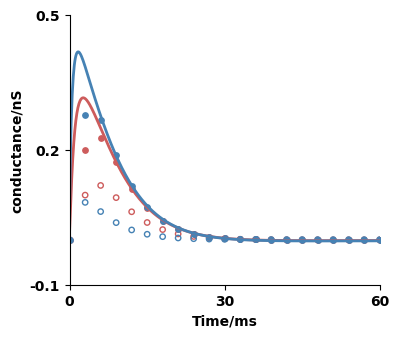

In [7]:
time = np.arange(0,len(GE_est))*0.1
s0 = 15
fig, ax2 = plt.subplots(1,1, figsize = (4,3.5))
plot_curve(ax2,time, GE_est*1e6, color='indianred', label='',
               xlim=[0,100], dx=50, linewidth=2, 
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS')

plot_curve(ax2,time[::30], intercept_effective_conductance[0,::30]*1e3, color='indianred',label='',
               xlim=[0,100], dx=50,
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='indianred')

plot_curve(ax2, time[::30], traditional_effective_conductance[0,::30]*1e3, color='indianred',label='',
               xlim=[0,1000], dx=500,
               ylim=[0, 2], dy  =0., ynum_decimals=1, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='none')

plot_curve(ax2,time, GI_est*1e6,color='steelblue',label='',
               xlim=[0,100], dx=50,linewidth=2, 
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS')

plot_curve(ax2, time[::30], 
           intercept_effective_conductance[1,::30]*1e3,color='steelblue',label='',
               xlim=[0,100], dx=50,
               ylim=[0, 2], dy=0., ynum_decimals=0, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='steelblue')

plot_curve(ax2, time[::30], 
           traditional_effective_conductance[1,::30]*1e3,color='steelblue',label='',
               xlim=[0,60], dx=30,
               ylim=[-0.1, 0.5], dy = 0.3, ynum_decimals=1, ylabel='conductance/nS',
               nonscatter=False, s0=s0, facecolor='none')
plt.savefig("pairEI_eff_con.eps", format='eps', dpi=300)
plt.show()
# ax2[1].set_title('active I')

# parallel

In [7]:
def error_eff_cond_est_two(run_dt, fE, fI, C=0.0006275253259611378, GL = 0.0002173680668463284,  locE=58, locI=37,
                         plot =False):
    
    neuron = Purkinje_py3()
        
    h.dt = run_dt
    h.tstop = 500.
    h.v_init =  -65.84
    Vclamp_init =  -65.84

    recv = h.Vector().record(neuron.soma(0.5)._ref_v)
    
    # Initialize an excitatory and inhibitory synaptic input
    # make a new stimulator
    stimE = h.NetStim()
    stimI = h.NetStim()

    synE = h.Exp2Syn(neuron.dend[int(locE)](0.5))
    synI = h.Exp2Syn(neuron.dend[int(locI)](0.5))
    synE.tau1 = 1.  # ms
    synE.tau2 = 5.  # ms
    synI.tau1 = 1.  # ms
    synI.tau2 = 5.  # ms

    synE.e = 0.  # mV for E input and -80 for I input 
    synI.e = -100.
        
    stimE.number = 1
    stimE.start = h.tstop - 100.  # ms
    stimI.number = 1
    stimI.start = h.tstop - 100.  # ms
    ncstimE = h.NetCon(stimE, synE)
    ncstimE.delay = 0.
    ncstimE.weight[0] = 0e-2  # uS
    ncstimI = h.NetCon(stimI, synI)
    ncstimI.delay = 0.
    ncstimI.weight[0] = 0e-2  # uS


    # Initialize voltage clamp
    vclamp = h.SEClamp(neuron.soma(0.5))
    vclamp.amp1 = Vclamp_init
    vclamp.dur1 = h.tstop
    vclamp.dur2 = h.tstop
    vclamp.amp2 = Vclamp_init - 20.

    irec = h.Vector()
    irec.record(vclamp._ref_i)

    # Function to initialize the simulation
    def initialize():
        h.t = 0
        h.finitialize(h.v_init)
        h.fcurrent()

    # Function to integrate the simulation
    def integrate():
        while h.t < h.tstop:
            h.fadvance()

    # Function to run the simulation
    def go():
        initialize()
        integrate()

    # Main simulation loop
    def main():

        Vclamp = np.arange(-110.,-60.,10)
        tstart = int(stimI.start/run_dt+1)
        V_rest = -65.84832151253157
        epsilonE = 0. - V_rest
        epsilonI = -100. - V_rest
        epsilonI1 = -120. - V_rest
        
        #  pure E for the estimation of true GE_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = fE
        ncstimI.weight[0] = 0.
        go()
        recvE0 = np.array(recv.to_python())
        recvE0_norm = recvE0[tstart:tstart+1000] - V_rest
        dVdtE = np.diff(recvE0_norm)/run_dt
        dVdtE = np.append(dVdtE, 0)
        GE_est = (C*dVdtE + GL*recvE0_norm)/(epsilonE - recvE0_norm)
        
        #  pure I input for the estimation of GI_est
        vclamp.dur1 = 0.
        vclamp.dur2 = 0.
        vclamp.dur3 = 0.
        ncstimE.weight[0] = 0.
        ncstimI.weight[0] = fI
        go()
        recvI0 = np.array(recv.to_python())
        recvI0_norm = recvI0[tstart:tstart+1000] - V_rest
        dVdtI = np.diff(recvI0_norm)/run_dt
        dVdtI = np.append(dVdtI, 0)
        GI_est = (C*dVdtI + GL*recvI0_norm)/(epsilonI - recvI0_norm)
        if plot:
            plt.plot(recvE0_norm, 'r')
            plt.plot(recvI0_norm, 'b')
        
        
    
        Isyn_inj_t = np.zeros((len(Vclamp),1000))
        Isyn_epsilonI1_inj_t = np.zeros((len(Vclamp),1000))

        

        for i in range(len(Vclamp)):
            ncstimE.weight[0] = 0.
            ncstimI.weight[0] = 0.
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj0 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            
            synE.e = 0.
            synI.e = -100.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn = (Iinj1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_inj_t[i,:] = Isyn
            
            synE.e = 0.
            synI.e = -120.
            ncstimE.weight[0] = fE
            ncstimI.weight[0] = fI
            vclamp.amp1 = Vclamp[i]
            vclamp.dur1 = h.tstop
            h.v_init = V_rest
            go()
            Iinj1_epsilonI1 = np.array(irec.to_python())  # Assuming irec is a NEURON Vector
            Isyn_epsilonI1 =  (Iinj1_epsilonI1[tstart:tstart+1000] - Iinj0[tstart:tstart+1000])
            Isyn_epsilonI1_inj_t[i,:] = Isyn_epsilonI1
            
                                                         
        traditional_effective_conductance = np.zeros((2,1000))
        intercept_effective_conductance = np.zeros((2,1000))
        A = np.ones((len(Vclamp),2))
        A[:,0] = Vclamp - V_rest
        epsilonE = 0. - V_rest
        epsilonI = -100. - V_rest
        epsilonI1 = -120. - V_rest
        relative_error = np.zeros(4)
        for i in range(1000):
            x, residuals, rank, singular_values = np.linalg.lstsq(A, Isyn_inj_t[:,i], 
                                                                  rcond=None)
            x_epsilonI1, residuals, rank, singular_values = np.linalg.lstsq(A, 
                                Isyn_epsilonI1_inj_t[:,i], rcond=None)
            
            traditional_effective_conductance[1, i] = (x[0]*epsilonE + x[1])/(epsilonE - epsilonI)
            traditional_effective_conductance[0, i] = (x[0]*epsilonI + x[1])/(epsilonI - epsilonE)
           
            intercept_effective_conductance[1,i] = (x[1] - x_epsilonI1[1])/(epsilonI1 - epsilonI)
            intercept_effective_conductance[0,i] = (-intercept_effective_conductance[1,i]*epsilonI - x[1])/epsilonE
        
        relative_error[0] = np.linalg.norm(GE_est*1e6-intercept_effective_conductance[0,:]*1e3)/np.linalg.norm(GE_est*1e6)
        relative_error[1] = np.linalg.norm(GE_est*1e6-traditional_effective_conductance[0,:]*1e3)/np.linalg.norm(GE_est*1e6)
        relative_error[2] = np.linalg.norm(GI_est*1e6-intercept_effective_conductance[1,:]*1e3)/np.linalg.norm(GI_est*1e6)
        relative_error[3] = np.linalg.norm(GI_est*1e6-traditional_effective_conductance[1,:]*1e3)/np.linalg.norm(GI_est*1e6)
        
        
        GE_est_norm = GE_est*1e6
        GI_est_norm = GI_est*1e6
        GE_est_inter = intercept_effective_conductance[0,:]*1e3  
        GE_est_trad = traditional_effective_conductance[0,:]*1e3
        GI_est_inter = intercept_effective_conductance[1,:]*1e3 
        GI_est_trad = traditional_effective_conductance[1,:]*1e3  
        return relative_error, GE_est_norm, GI_est_norm, GE_est_inter, GE_est_trad, GI_est_inter, GI_est_trad
    
    
    relative_error, GE_est_norm, GI_est_norm, GE_est_inter, GE_est_trad, GI_est_inter, GI_est_trad= main()
    N = len(relative_error) + len(GE_est_norm) + len(GI_est_norm) + len(GE_est_inter) + len(GE_est_trad) + len(GI_est_inter) + len(GI_est_trad)
    N1 = len(relative_error)
    N2 = N1 + len(GE_est_norm)
    N3 = N2 + len(GI_est_norm)
    N4 = N3 + len(GE_est_inter)
    N5 = N4 + len(GE_est_trad)
    N6 = N5 + len(GI_est_inter)
    N7 = N6 + len(GI_est_trad)
    results = np.zeros(N)
    results[:N1] = relative_error
    results[N1:N2] = GE_est_norm
    results[N2:N3] = GI_est_norm
    results[N3:N4] = GE_est_inter
    results[N4:N5] = GE_est_trad
    results[N5:N6] = GI_est_inter
    results[N6:N7] = GI_est_trad
    return results

In [8]:
stimu0 = 100
results = error_eff_cond_est_two(0.1, 2e-3, 2e-3,
            plot=False, locE=stimu0, locI=stimu0 + 200)

In [9]:
# Your existing functions and code
def error_eff_cond_est_two_parallel(args,):
    stimu0, = args
    results = error_eff_cond_est_two(0.1, 2e-3, 2e-3,
            plot=False, locE=stimu0, locI=stimu0)
     
    return results

stimu = np.arange(0, 1599, 1)
# # 生成网格
# X, Y = np.meshgrid(loc, loc)

# # 将网格重塑为9x9的数组
# # 首先将X和Y平铺为一维数组，然后将这两个数组堆叠成二维数组，每一行是一个(x,y)对
# stimu = np.vstack([X.ravel(), Y.ravel()]).T

# Create a Pool with desired number of processes (adjust as needed)
num_processes = 55
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(stimu0,) for stimu0 in stimu]

    # Apply the function in parallel
    results = pool.map(error_eff_cond_est_two_parallel, args_list)


results_total = np.zeros((len(stimu), 6004))

for i, result in enumerate(results):
    results_total[i, :] = result
np.savetxt("pair_eff_cond_E2e3_I2e3_whole.txt", results_total)

In [2]:
results_total = np.loadtxt("pair_eff_cond_E2e3_I2e3_whole.txt")
relative_error = results_total[:, :4]
GE_est_norm = results_total[:, 4:1004]
GI_est_norm = results_total[:, 1004:2004]
GE_est_inter = results_total[:, 2004:3004]
GE_est_trad = results_total[:, 3004:4004]
GI_est_inter = results_total[:, 4004:5004]
GI_est_trad = results_total[:, 5004:6004]
relative_error_mean = np.mean(relative_error,axis=0)
GE_est_inter_mean = np.mean(GE_est_inter, axis=1)
GE_est_norm_mean = np.mean(GE_est_norm, axis=1)
GI_est_norm_mean = np.mean(GI_est_norm, axis=1)
GE_est_trad_mean = np.mean(GE_est_trad, axis=1)
GI_est_inter_mean = np.mean(GI_est_inter, axis=1)
GI_est_trad_mean = np.mean(GI_est_trad, axis=1)
negative_GE_est_inter = np.sum(GE_est_inter_mean<0)
negative_GE_est_trad = np.sum(GE_est_trad_mean<0)
negative_GI_est_inter = np.sum(GI_est_inter_mean<0)
negative_GI_est_trad = np.sum(GI_est_trad_mean<0)
negative_GE_est_norm = np.sum(GE_est_norm_mean<0)
negative_GI_est_norm = np.sum(GI_est_norm_mean<0)
# mean error
error_mean = np.zeros_like(relative_error)
error_mean[:,0] = np.abs(np.mean(GE_est_norm,axis=1) - np.mean(GE_est_inter, axis=1))/np.mean(GE_est_norm,axis=1)
error_mean[:,1] = np.abs(np.mean(GE_est_norm,axis=1) - np.mean(GE_est_trad, axis=1))/np.mean(GE_est_norm,axis=1)
error_mean[:,2] = np.abs(np.mean(GI_est_norm,axis=1) - np.mean(GI_est_inter, axis=1))/np.mean(GI_est_norm,axis=1)
error_mean[:,3] = np.abs(np.mean(GI_est_norm,axis=1) - np.mean(GI_est_trad, axis=1))/np.mean(GI_est_norm,axis=1)


In [3]:
print(np.mean(error_mean,axis=0))

[0.2079782  0.53964705 0.19724537 0.85302744]


In [8]:
print(np.min(error_mean,axis=0))

[0.18983523 0.31523369 0.18059586 0.42551057]


(1599, 4)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


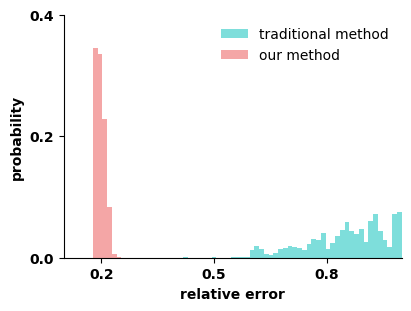

In [5]:
# distance = np.loadtxt('pairEI_distance.txt')
# relative_error = np.loadtxt('pair_eff_cond_relative_error_E6e3_I3e3_whole.txt')

error = error_mean
# print(np.shape(distance))
print(np.shape(error))
fontsize = 10
bins = np.linspace(0,1.0,80)
# 定义误差和 bin 范围
min_bin = bins[0]  # bins的最小值
max_bin = bins[-1]  # bins的最大值

# 将 error 限制在 [min_bin, max_bin] 之间
clipped_error_our = np.clip(error[:,2], min_bin, max_bin)
clipped_error_trad = np.clip(error[:,3], min_bin, max_bin)

fig, ax1 = plt.subplots(1,1,figsize=(4,3), constrained_layout=True)
nE_our,binsE_our = np.histogram(clipped_error_our,bins=bins)
nE_trad,binsE_trad = np.histogram(clipped_error_trad,bins=bins)
widths = bins[2]-bins[1]
ax1.bar(bins[:-1], nE_trad/np.sum(nE_trad), zorder=1, align='edge', width=widths, 
        color='mediumturquoise',alpha=0.7, edgecolor = None,  linewidth=1,label='traditional method')
ax1.bar(bins[:-1], nE_our/np.sum(nE_our), zorder=1, align='edge', width=widths,
        color='lightcoral',alpha=0.7, edgecolor = None,  linewidth=1,label='our method')


ax1.set_xlabel('relative error',fontsize=fontsize,weight='bold')
ax1.set_ylabel('probability',fontsize=fontsize,weight='bold')
ax1.set_xticks(np.arange(0.2,1.1,0.3))
ax1.set_yticks(np.arange(0,0.5,0.2))
ax1.set_xticklabels(np.arange(0.2,1.1,0.3),fontsize=fontsize,weight='bold')
ax1.set_yticklabels(np.arange(0,0.5,0.2),fontsize=fontsize,weight='bold')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_ylim([0,0.4])
ax1.set_xlim([0.1,1.0])
ax1.legend(loc='best',fontsize=fontsize,edgecolor='white')
# ax1.set_title('E',fontsize=fontsize,weight='bold')
plt.savefig('relative_error_eff_con_I.eps')

(1599, 4)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


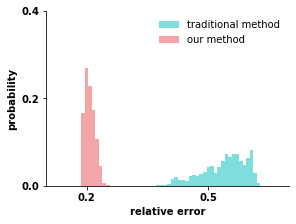

In [36]:
# distance = np.loadtxt('pairEI_distance.txt')
# relative_error = np.loadtxt('pair_eff_cond_relative_error_E6e3_I3e3_whole.txt')

error = error_mean
# print(np.shape(distance))
print(np.shape(error))
fontsize = 10
bins = np.linspace(0,0.7,80)
fig, ax1 = plt.subplots(1,1,figsize=(4,3), constrained_layout=True)
nE_our,binsE_our = np.histogram(error[:,0],bins=bins)
nE_trad,binsE_trad = np.histogram(error[:,1],bins=bins)
widths = bins[2]-bins[1]
ax1.bar(bins[:-1], nE_trad/np.sum(nE_trad), zorder=1, align='edge', width=widths, 
        color='mediumturquoise',alpha=0.7, edgecolor = None,  linewidth=1,label='traditional method')
ax1.bar(bins[:-1], nE_our/np.sum(nE_our), zorder=1, align='edge', width=widths,
        color='lightcoral',alpha=0.7, edgecolor = None,  linewidth=1,label='our method')


ax1.set_xlabel('relative error',fontsize=fontsize,weight='bold')
ax1.set_ylabel('probability',fontsize=fontsize,weight='bold')
ax1.set_xticks(np.arange(0.2,1.1,0.3))
ax1.set_yticks(np.arange(0,0.5,0.2))
ax1.set_xticklabels(np.arange(0.2,1.1,0.3),fontsize=fontsize,weight='bold')
ax1.set_yticklabels(np.arange(0,0.5,0.2),fontsize=fontsize,weight='bold')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_ylim([0,0.4])
ax1.set_xlim([0.1,0.7])
ax1.legend(loc='best',fontsize=fontsize,edgecolor='white')
# ax1.set_title('E',fontsize=fontsize,weight='bold')
plt.savefig('relative_error_eff_con_E.eps')

[0. 0.]


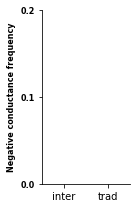

In [39]:
import matplotlib.pyplot as plt


# y_values = np.array([negative_GI_est_inter, negative_GI_est_trad])/len(GI_est_inter_mean)
x_values = ['inter', 'trad']
y_values = np.array([negative_GE_est_inter, negative_GE_est_trad])/len(GE_est_inter_mean)
print(y_values)


# 指定每个条形的位置
positions = [1.5, 2.5]  # 注意x1和x2之间的距离小于x2和x3之间的距离

fig, ax = plt.subplots(1,1, figsize = (2,3))
ax.bar(positions, y_values, tick_label=x_values, color = ['lightcoral',  'mediumturquoise'],width=0.5)

# 添加标签和标题
# plt.xlabel('Variables')
ylim=[0,0.2]
dy=0.1
fontsize=8
ynum_decimals = 1
ax.set_ylabel('Negative conductance frequency', fontsize=fontsize, weight='bold')
ax.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
ax.set_yticklabels(ax.get_yticks(), fontsize=fontsize, weight='bold')
ax.set_ylim([ylim[0], ylim[1]])
ax.set_xlim([1, 3])
def format_funcy(value, tick_number, num_decimals=ynum_decimals):
    if num_decimals==0:
        return f'{value:.0f}'
    return f'{value:.{num_decimals}f}'
ax.yaxis.set_major_formatter(FuncFormatter(format_funcy))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("negative_distr_E.eps", format='eps', dpi=300)


[0.         0.00875547]


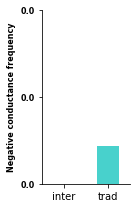

In [45]:
import matplotlib.pyplot as plt


y_values = np.array([negative_GI_est_inter, negative_GI_est_trad])/len(GI_est_inter_mean)
x_values = ['inter', 'trad']
# y_values = np.array([negative_GE_est_inter, negative_GE_est_trad])/len(GE_est_inter_mean)
print(y_values)


# 指定每个条形的位置
positions = [1.5, 2.5]  # 注意x1和x2之间的距离小于x2和x3之间的距离

fig, ax = plt.subplots(1,1, figsize = (2,3))
ax.bar(positions, y_values, tick_label=x_values, color = ['lightcoral',  'mediumturquoise'],width=0.5)

# 添加标签和标题
# plt.xlabel('Variables')
ylim=[0,0.04]
dy=0.02
fontsize=8
ynum_decimals = 1
ax.set_ylabel('Negative conductance frequency', fontsize=fontsize, weight='bold')
ax.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
ax.set_yticklabels(ax.get_yticks(), fontsize=fontsize, weight='bold')
ax.set_ylim([ylim[0], ylim[1]])
ax.set_xlim([1, 3])
def format_funcy(value, tick_number, num_decimals=ynum_decimals):
    if num_decimals==0:
        return f'{value:.0f}'
    return f'{value:.{num_decimals}f}'
ax.yaxis.set_major_formatter(FuncFormatter(format_funcy))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("negative_distr_I.eps", format='eps', dpi=300)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


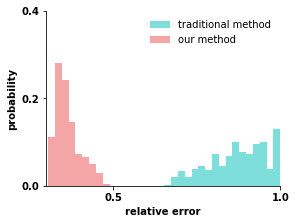

In [25]:
fontsize = 10
bins = np.linspace(0,1,50)
fig, ax1 = plt.subplots(1,1,figsize=(4,3), constrained_layout=True)
nE_our,binsE_our = np.histogram(relative_error[:,2],bins=bins)
nE_trad,binsE_trad = np.histogram(relative_error[:,3],bins=bins)
widths = bins[2]-bins[1]
ax1.bar(bins[:-1], nE_trad/np.sum(nE_trad), zorder=1, align='edge', width=widths, 
        color='mediumturquoise',alpha=0.7, edgecolor = None,  linewidth=1,label='traditional method')
ax1.bar(bins[:-1], nE_our/np.sum(nE_our), zorder=1, align='edge', width=widths,
        color='lightcoral',alpha=0.7, edgecolor = None,  linewidth=1,label='our method')


ax1.set_xlabel('relative error',fontsize=fontsize,weight='bold')
ax1.set_ylabel('probability',fontsize=fontsize,weight='bold')
ax1.set_xticks(np.arange(0,1.2,0.5))
ax1.set_yticks(np.arange(0,0.5,0.2))
ax1.set_xticklabels(np.arange(0,1.2,0.5),fontsize=fontsize,weight='bold')
ax1.set_yticklabels(np.arange(0,0.5,0.2),fontsize=fontsize,weight='bold')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_ylim([0,0.4])
ax1.set_xlim([0.3,1.])
ax1.legend(loc='best',fontsize=fontsize,edgecolor='white')
# ax1.set_title('E',fontsize=fontsize,weight='bold')
plt.savefig('relative_error_eff_con_I.eps')

In [36]:
relative_error_mean = np.mean(relative_error,axis=0)
GE_est_inter_mean = np.mean(GE_est_inter, axis=1)
GE_est_norm_mean = np.mean(GE_est_norm, axis=1)
GI_est_norm_mean = np.mean(GI_est_norm, axis=1)
GE_est_trad_mean = np.mean(GE_est_trad, axis=1)
GI_est_inter_mean = np.mean(GI_est_inter, axis=1)
GI_est_trad_mean = np.mean(GI_est_trad, axis=1)
negative_GE_est_inter = np.sum(GE_est_inter_mean<0)
negative_GE_est_trad = np.sum(GE_est_trad_mean<0)
negative_GI_est_inter = np.sum(GI_est_inter_mean<0)
negative_GI_est_trad = np.sum(GI_est_trad_mean<0)
negative_GE_est_norm = np.sum(GE_est_norm_mean<0)
negative_GI_est_norm = np.sum(GI_est_norm_mean<0)
print(negative_GE_est_inter)
print(negative_GI_est_inter)
# print(np.where(GE_est_inter_mean<0)[0][0])

0
0


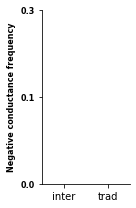

In [38]:
import matplotlib.pyplot as plt


# y_values = np.array([negative_GI_est_inter, negative_GI_est_trad])/len(GE_est_inter_mean)
x_values = ['inter', 'trad']
y_values = np.array([negative_GE_est_inter, negative_GE_est_trad])/len(GE_est_inter_mean)


# 指定每个条形的位置
positions = [1.5, 2.5]  # 注意x1和x2之间的距离小于x2和x3之间的距离

fig, ax = plt.subplots(1,1, figsize = (2,3))
ax.bar(positions, y_values, tick_label=x_values, color = ['lightcoral',  'mediumturquoise'],width=0.5)

# 添加标签和标题
# plt.xlabel('Variables')
ylim=[0,0.3]
dy=0.15
fontsize=8
ynum_decimals = 1
ax.set_ylabel('Negative conductance frequency', fontsize=fontsize, weight='bold')
ax.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
ax.set_yticklabels(ax.get_yticks(), fontsize = fontsize, weight='bold')
ax.set_ylim([ylim[0], ylim[1]])
ax.set_xlim([1, 3])
def format_funcy(value, tick_number, num_decimals=ynum_decimals):
    if num_decimals==0:
        return f'{value:.0f}'
    return f'{value:.{num_decimals}f}'
ax.yaxis.set_major_formatter(FuncFormatter(format_funcy))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig("/home/wzl/LFPy/project/conductance_measurement/realistic_neuron/figure/figure4/negative_distr_E.eps", format='eps', dpi=300)


In [24]:
def caculate_distance(locnumE):
     
    neuron = Purkinje_py3()
    x_soma = (neuron.soma.x3d(0)+ neuron.soma.x3d(1))/2.
    y_soma = (neuron.soma.y3d(0)+ neuron.soma.y3d(1))/2.
    z_soma = (neuron.soma.z3d(0)+ neuron.soma.z3d(1))/2.

    x_synE = (neuron.dend[int(locnumE)].x3d(0)+ neuron.dend[int(locnumE)].x3d(1))/2.
    y_synE = (neuron.dend[int(locnumE)].y3d(0)+ neuron.dend[int(locnumE)].y3d(1))/2.
    z_synE = (neuron.dend[int(locnumE)].z3d(0)+ neuron.dend[int(locnumE)].z3d(1))/2.
 
        
    distance = np.sqrt((x_soma-x_synE)**2 + (y_soma-y_synE)**2 + (z_soma-z_synE)**2)
    
    return distance

In [8]:
def caculate_distance_parallel(args,):
    loc0, = args
    distance = caculate_distance(loc0)      
    return distance

loc=np.arange(0, 1599, 1)
distance = np.zeros(len(loc))
# Create a Pool with desired number of processes (adjust as needed)
num_processes = 55
with Pool(num_processes) as pool:
    # Prepare arguments for parallel processing
    args_list = [(loc0,) for loc0 in loc]

    # Apply the function in parallel
    results = pool.map(caculate_distance_parallel, args_list)

distance = results

In [9]:
np.savetxt('dend_distance.txt', distance)

In [10]:
print(np.max(distance))

279.4595734450385
